# ADVANCED MORPHOMETRY & TOPOLOGICAL METRICS PIPELINE FOR MATERIAL RESEARCHERS
Student Action Required Before Execution:
* To test this code with the attached sample image (image.png), verify the workspace path and adapt the dimensions to match your file coordinates:
 1. Filename: image.png
 2. Resolution Scale: Width = 893 pixels, Height = 899 pixels

🚀 Initializing Material Analysis Pipeline...


/tmp/ipykernel_694608/3703092895.py:46: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = morphology.remove_small_objects(binary_mask, min_size=50)
/tmp/ipykernel_694608/3703092895.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  cleaned_mask = morphology.binary_closing(cleaned_mask, morphology.disk(2))


📋 Tier 1: Computing Standard Geometric Descriptors...
🔬 Tier 2: Unlocking Non-Standard Spatial & Surface Texture Analytics...
📊 Compiling Publication-Grade Figures...


/tmp/ipykernel_694608/3703092895.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/llinersy/Documents/Eventos/Organizacion_de_eventos/2026/Module4-Image_Processing/venv_lppi/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/llinersy/Documents/Eventos/Organizacion_de_eventos/2026/Module4-Image_Processing/venv_lppi/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


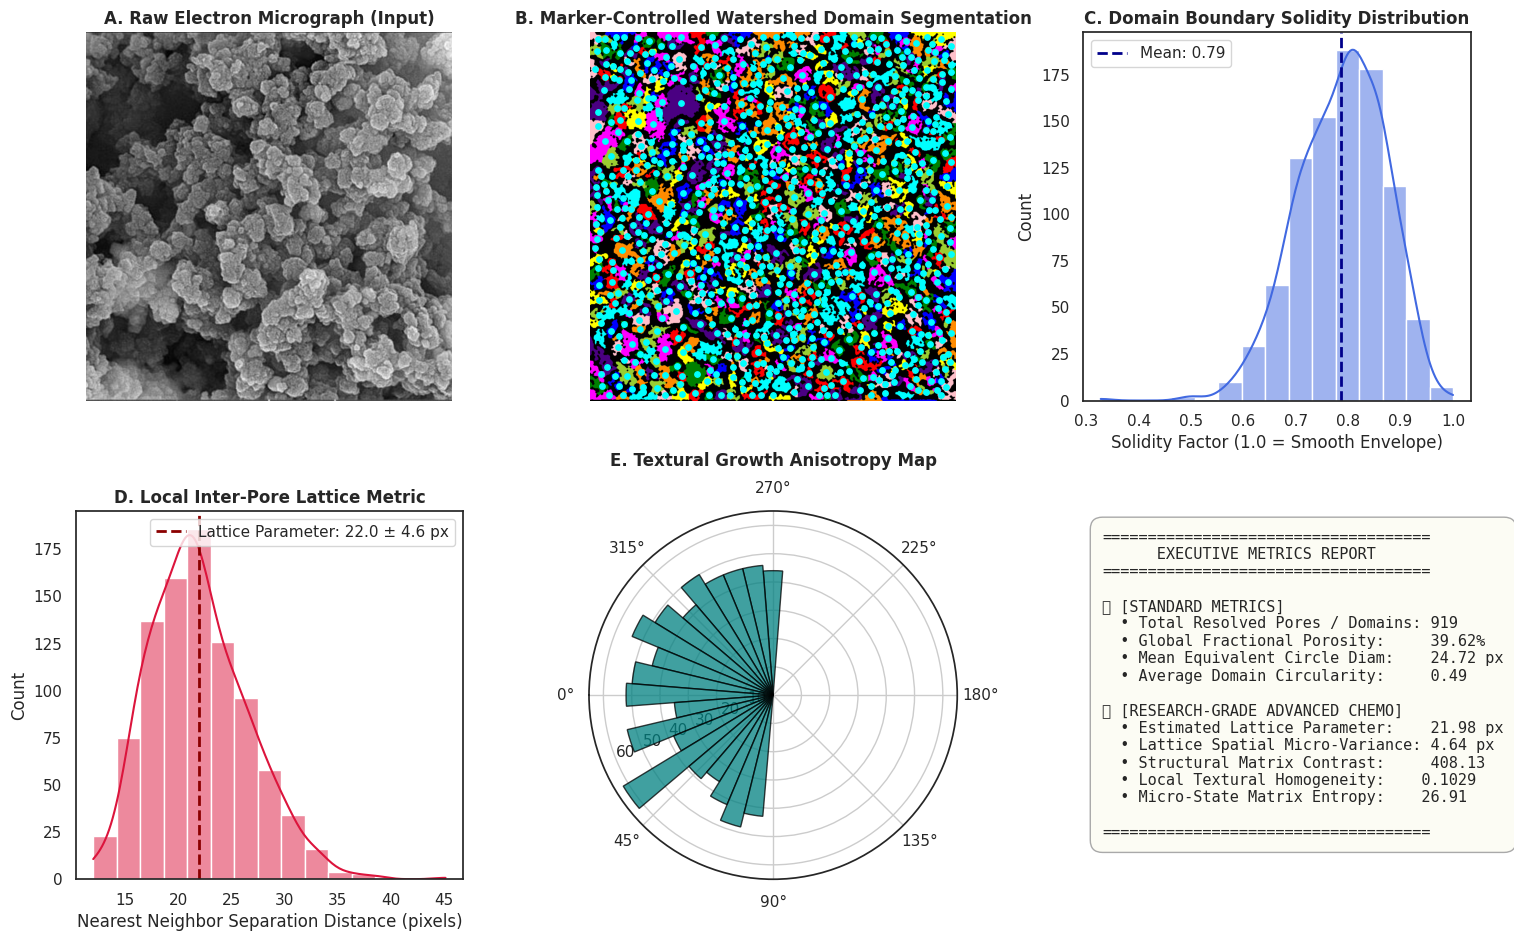

In [5]:
# Author: Llinersy Uranga Pina, LPPI - Cergy-Paris Université
# ==============================================================================
# ADVANCED MORPHOMETRY & TOPOLOGICAL METRICS PIPELINE FOR MATERIAL RESEARCHERS
# ==============================================================================
# This notebook demonstrates how to extract standard structural descriptors
# and research-grade network/texture signatures directly from micrographs.

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage as ndi
from scipy.spatial import distance_matrix

# Image Processing Tools
from skimage import filters, measure, morphology, segmentation, color, feature
from skimage.feature import graycomatrix, graycoprops

def advanced_material_micrograph_analytics(filepath="image.png", target_width=893, target_height=899):
    """
    Executes an end-to-end multi-tier analysis framework from baseline segmentation
    up to advanced structural network, texturing, and proximity topology calculations.
    """
    if not os.path.exists(filepath):
        print(f"❌ Target File Not Found at '{filepath}'. Please check your file path or spelling.")
        return None

    print("🚀 Initializing Material Analysis Pipeline...")
    
    # --------------------------------------------------------------------------
    # STEP 1: RESTRENGTHENING RAW IMAGE MATRIX & CORE BINARIZATION
    # --------------------------------------------------------------------------
    raw_gray = cv2.imread(filepath, 0)
    img = cv2.resize(raw_gray, (target_width, target_height), interpolation=cv2.INTER_AREA)
    norm_img = img / 255.0  # Float conversion for robust filtering math
    
    # Median filtering to eliminate electronic noise while preserving sharp solid/void interfaces
    denoised = filters.median(norm_img, morphology.disk(2))
    
    # Local adaptive thresholding to account for uneven illumination or shadow gradients
    thresh_local = filters.threshold_local(denoised, block_size=45, offset=0.01)
    binary_mask = denoised > thresh_local
    
    # Morphological purification to remove non-physical noise remnants
    cleaned_mask = morphology.remove_small_objects(binary_mask, min_size=50)
    cleaned_mask = morphology.binary_closing(cleaned_mask, morphology.disk(2))
    
    # --------------------------------------------------------------------------
    # STEP 2: MARKER-CONTROLLED WATERSHED SEGMENTATION (Pore Separation)
    # --------------------------------------------------------------------------
    distance_map = ndi.distance_transform_edt(cleaned_mask)
    local_maxi_coords = feature.peak_local_max(distance_map, min_distance=12, labels=cleaned_mask)
    
    seed_mask = np.zeros(distance_map.shape, dtype=bool)
    seed_mask[tuple(local_maxi_coords.T)] = True
    markers, _ = ndi.label(seed_mask)
    
    labeled_domains = segmentation.watershed(-distance_map, markers, mask=cleaned_mask)
    
    # --------------------------------------------------------------------------
    # LEVEL A: STANDARD BENCHTOP MORPHOMETRY (Commercial Software Baseline)
    # --------------------------------------------------------------------------
    print("📋 Tier 1: Computing Standard Geometric Descriptors...")
    
    standard_props = measure.regionprops_table(
        labeled_domains, 
        intensity_image=img,
        properties=['label', 'area', 'equivalent_diameter', 'eccentricity', 'solidity', 'orientation']
    )
    df = pd.DataFrame(standard_props)
    
    # Derived parameters: Aspect Ratio and Circularity
    df['aspect_ratio'] = np.tan(df['orientation']) # Proxy for shape distortion vector
    perimeters = [measure.perimeter(labeled_domains == row.label) for row in df.itertuples()]
    df['circularity'] = (4 * np.pi * df['area']) / (np.array(perimeters) ** 2)
    # Correct any minor floating point errors above 1.0
    df['circularity'] = df['circularity'].clip(upper=1.0) 
    
    global_porosity = (np.sum(cleaned_mask == 0) / norm_img.size) * 100
    
    # --------------------------------------------------------------------------
    # LEVEL B: RESEARCH-GRADE CHEMOMETRICS (Advanced Topological Extensions)
    # --------------------------------------------------------------------------
    print("🔬 Tier 2: Unlocking Non-Standard Spatial & Surface Texture Analytics...")
    
    # --- Metric 1: Nearest-Neighbor Inter-Pore Spacing Profile ---
    pore_centers = local_maxi_coords
    if len(pore_centers) > 2:
        dist_mat = distance_matrix(pore_centers, pore_centers)
        np.fill_diagonal(dist_mat, np.inf) # Disregard distance to oneself
        nearest_neighbor_distances = np.min(dist_mat, axis=1)
        mean_lattice_spacing = np.mean(nearest_neighbor_distances)
        std_lattice_spacing = np.std(nearest_neighbor_distances)
    else:
        mean_lattice_spacing, std_lattice_spacing = 0, 0
        nearest_neighbor_distances = [0]
        
    # --- Metric 2: Image Texturing Entropy & Homogeneity (GLCM Analysis) ---
    # Convert image back to integer format for co-occurrence processing steps
    img_uint8 = (norm_img * 255).astype(np.uint8)
    glcm = graycomatrix(img_uint8, distances=[3], angles=[0, np.pi/4], levels=256, symmetric=True, normed=True)
    
    texture_homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    texture_contrast = graycoprops(glcm, 'contrast')[0, 0]
    # Calculate Texture Entropy: Measure of local structural disorder
    texture_entropy = -np.sum(glcm * np.log2(glcm + 1e-10))

    # --------------------------------------------------------------------------
    # STEP 3: HIGH-FIDELITY RESEARCH PANEL VISUALIZATION
    # --------------------------------------------------------------------------
    print("📊 Compiling Publication-Grade Figures...")
    sns.set_theme(style="white")
    
    fig = plt.figure(figsize=(18, 11))
    grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.3)
    
    # Plot 1: Raw Original Input
    ax_raw = fig.add_subplot(grid[0, 0])
    ax_raw.imshow(img, cmap='gray')
    ax_raw.set_title("A. Raw Electron Micrograph (Input)", fontsize=12, fontweight='bold')
    ax_raw.axis('off')
    
    # Plot 2: Segmented Watershed Boundaries Map
    ax_seg = fig.add_subplot(grid[0, 1])
    ax_seg.imshow(color.label2rgb(labeled_domains, bg_label=0))
    ax_seg.scatter(pore_centers[:, 1], pore_centers[:, 0], color='cyan', s=15, label='Resolved Nodes')
    ax_seg.set_title("B. Marker-Controlled Watershed Domain Segmentation", fontsize=12, fontweight='bold')
    ax_seg.axis('off')
    
    # Plot 3: Solidity Distribution Profile (Standard Feature)
    ax_solid = fig.add_subplot(grid[0, 2])
    sns.histplot(df['solidity'], bins=15, kde=True, color='royalblue', ax=ax_solid)
    ax_solid.axvline(df['solidity'].mean(), color='darkblue', linestyle='--', linewidth=2, label=f"Mean: {df['solidity'].mean():.2f}")
    ax_solid.set_title("C. Domain Boundary Solidity Distribution", fontsize=12, fontweight='bold')
    ax_solid.set_xlabel("Solidity Factor (1.0 = Smooth Envelope)")
    ax_solid.legend()
    
    # Plot 4: Nearest Neighbor Inter-Pore Spacing Vector Graph (Research Feature)
    ax_space = fig.add_subplot(grid[1, 0])
    sns.histplot(nearest_neighbor_distances, bins=15, kde=True, color='crimson', ax=ax_space)
    ax_space.axvline(mean_lattice_spacing, color='darkred', linestyle='--', linewidth=2, 
                     label=f"Lattice Parameter: {mean_lattice_spacing:.1f} ± {std_lattice_spacing:.1f} px")
    ax_space.set_title("D. Local Inter-Pore Lattice Metric", fontsize=12, fontweight='bold')
    ax_space.set_xlabel("Nearest Neighbor Separation Distance (pixels)")
    ax_space.legend()

    # Plot 5: Spatial Orientation Anisotropy Map
    ax_orient = fig.add_subplot(grid[1, 1], projection='polar')
    ax_orient.set_theta_offset(np.pi)
    # Transform coordinates from radians to polar alignment constraints
    angles = df['orientation']
    counts, bins = np.histogram(angles, bins=20)
    widths = np.diff(bins)
    ax_orient.bar(bins[:-1], counts, width=widths, color='teal', edgecolor='black', alpha=0.75)
    ax_orient.set_title("E. Textural Growth Anisotropy Map", fontsize=12, fontweight='bold', y=1.1)
    
    # Panel 6: Metadata Consolidated Executive Summary Box
    ax_summary = fig.add_subplot(grid[1, 2])
    ax_summary.axis('off')
    summary_text = (
        f"====================================\n"
        f"      EXECUTIVE METRICS REPORT       \n"
        f"====================================\n\n"
        f"🔬 [STANDARD METRICS]\n"
        f"  • Total Resolved Pores / Domains: {len(df)}\n"
        f"  • Global Fractional Porosity:     {global_porosity:.2f}%\n"
        f"  • Mean Equivalent Circle Diam:    {df['equivalent_diameter'].mean():.2f} px\n"
        f"  • Average Domain Circularity:     {df['circularity'].mean():.2f}\n\n"
        f"🧬 [RESEARCH-GRADE ADVANCED CHEMO]\n"
        f"  • Estimated Lattice Parameter:    {mean_lattice_spacing:.2f} px\n"
        f"  • Lattice Spatial Micro-Variance: {std_lattice_spacing:.2f} px\n"
        f"  • Structural Matrix Contrast:     {texture_contrast:.2f}\n"
        f"  • Local Textural Homogeneity:    {texture_homogeneity:.4f}\n"
        f"  • Micro-State Matrix Entropy:    {texture_entropy:.2f}\n\n"
        f"===================================="
    )
    ax_summary.text(0.05, 0.95, summary_text, transform=ax_summary.transAxes,
                    fontsize=11, fontfamily='monospace', va='top',
                    bbox=dict(boxstyle='round,pad=0.8', facecolor='#fcfcf4', edgecolor='darkgray'))

    plt.tight_layout()
    plt.show()
    
    return df

# ==============================================================================
# LOCAL EXECUTION BLOCK
# ==============================================================================
# Un-comment the line below to run this complete analytical pipeline in your notebook:
material_database = advanced_material_micrograph_analytics("image.png", 893, 899)